# Information Extraction - Exploratory Notebook - Version 3
## Purpose
Changes to Version 3

- Stem or lemmatise tokens
- Cross validation
- Add ROC analysis
---
---


## Step 1: Import packages and dataset
As before, we use the requirements.txt file to install our required packages.

In [1]:
# Before we import our packages, we need to have the installed on our local machine. Use a combinaion of pip and the requirements.txt file for this.
# note, remove the -q flag to increase verbosity. 
%pip install -q -r requirements.txt

You should consider upgrading via the '/Users/sbrv951/Documents/CodeLibrary/MissingDataPredictor/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# import packages into our python environment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import re


In [3]:
# install data
data = pd.read_csv('crime_data.csv')

/var/folders/1z/z4nfsvpx2177t7xs71wckg2c7zwknv/T/ipykernel_89111/2338300253.py:2: DtypeWarning: Columns (16,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('crime_data.csv')


## Step 2: Remap Vict-Offender Relationship column with new labels
As before, we now need to remap the 56 labels in the Vict-Offender Relationship column with the new macro labels.

In [4]:
# filter the dataframe to include only the columns we're interested in
cols = [
    'VIC OFFENDER RELATIONSHIP',
    'CRIME NOTES'
]

data_f = data[cols]

# remove NaNs
data_f3 = data_f.dropna(subset=['CRIME NOTES','VIC OFFENDER RELATIONSHIP'])

# separate the rows where VIC OFFENDER RELATIONSHIP is empty and store that as an unlabelled dataset.
unlabelled_data = data_f3[data_f3['VIC OFFENDER RELATIONSHIP'].isna()]


In [5]:
# use the vic_offender_remapping.csv file to map exiting categories to new ones
mapping_df = pd.read_csv('v2_vic_offender_remapping.csv', delimiter=',')
mapping_df.columns = mapping_df.columns.str.strip()

# map the values in the VIC OFFENDER COLUMN to the corresponding values in the mapping DF
data_f3.loc[:, 'remapped_cats'] = data_f3.loc[:, 'VIC OFFENDER RELATIONSHIP'].map(mapping_df.set_index('value')['mapping'])
print(len(data_f3))
data_f3.head(10)

14081


/var/folders/1z/z4nfsvpx2177t7xs71wckg2c7zwknv/T/ipykernel_89111/1825331738.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_f3.loc[:, 'remapped_cats'] = data_f3.loc[:, 'VIC OFFENDER RELATIONSHIP'].map(mapping_df.set_index('value')['mapping'])


,VIC OFFENDER RELATIONSHIP,CRIME NOTES,remapped_cats
2,BOYFRIEND/GIRLFRIEND,MARK PUSHES ZOE TO WAKE HER UP AND THIS RESULT...,partner
3,EX PARTNER,THIRD HAND REPORT OF DOMESTIC ASSAULT. PATROL ...,ex_partner
4,BOYFRIEND/GIRLFRIEND,KNOWN OFFENDER CAUSED BROKEN BONES AND FACIAL ...,partner
5,EX PARTNER,SUSPECT HAS APPROACHED EX PARTNER WHILST HER V...,ex_partner
6,OTHER,HAPPENED 06/07/16 APPROX 0600 HOURS ON THE INF...,other
7,BOYFRIEND/GIRLFRIEND,FEMALE HAS BEEN AT HOME WITH HER CHILDREN WHEN...,partner
8,EX PARTNER,POLICE CALLED TO VERBAL ONLY DOMESTIC. UPON HA...,ex_partner
9,BOYFRIEND/GIRLFRIEND,"B173***SEC 39 ASSAULT, THREATS TO KILL. DOMEST...",partner
10,BOYFRIEND/GIRLFRIEND,B162 CRIME *** SECTIO 47 ASSAULT****GOLD DOMES...,partner
11,BOYFRIEND/GIRLFRIEND,REPORT FROM THIRD PARTY THAT SUSPECT HAS MADE ...,partner


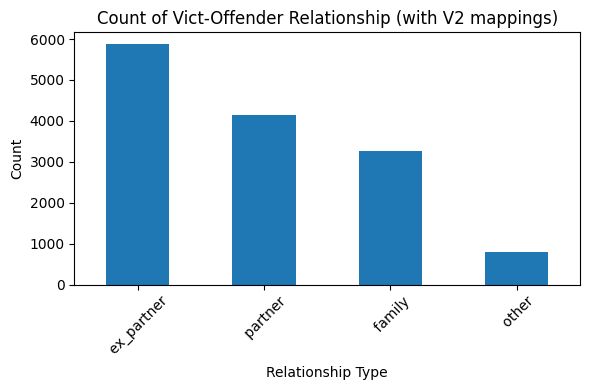

In [6]:
# we can now visualise a count of each type of relationship the remapped column
remapped_cats_counts = data_f3['remapped_cats'].value_counts()

# we can then create a bar chart demonstrating the counts
plt.figure(figsize=(6, 4))
remapped_cats_counts.plot(kind='bar')
plt.title('Count of Vict-Offender Relationship (with V2 mappings)')
plt.xlabel('Relationship Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/remapping_counts.png')
plt.show()

Compared with the previous version (v1), we now have four classes of relationship. 

In [7]:
# remove 'others' category
data_f3['remapped_cats'] = data_f3['remapped_cats'].str.strip().str.lower()
data_f4 = data_f3[data_f3['remapped_cats']!='other']

# check the filtered dataset
data_f4.shape

/var/folders/1z/z4nfsvpx2177t7xs71wckg2c7zwknv/T/ipykernel_89111/3906941531.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_f3['remapped_cats'] = data_f3['remapped_cats'].str.strip().str.lower()


(13290, 3)

## Step 3: Clean the pre-process the unstructured text in the CRIME NOTES column.
This step continues to use the TF-IDF algorithm to engineer features.

In [11]:
# given that the text appears in upper casing, we should convert the text to lower casing as our algorithms will work better.
data_f4.loc[:, 'text_processed'] = data_f4['CRIME NOTES'].str.lower()

# we should also remove punctuation and numbers to reduce noise when training the model.
data_f4.loc[:, 'text_processed'] = data_f4.loc[:, 'text_processed'].apply(lambda x: re.sub(r'[^\w\s]|(\d+)','', x))

# download the list of stopwords 
nltk.download('stopwords')

# store the stop words in a Set
stop_words = set(stopwords.words('english'))

# search through each word in each row, and remove any words that appear in the list of stop words
data_f4.loc[:, 'text_processed_no_sw'] = data_f4['text_processed'].apply(lambda x: ' '.join(word for word in x.split() if word not in stop_words))

# stem remaining words
from nltk.stem.porter import PorterStemmer

stemmer = PorterStemmer()

# apply stemmer
data_f4.loc[:, 'text_processed_no_sw_stem'] = data_f4['text_processed_no_sw'].apply(lambda x: ' '.join(stemmer.stem(word) for word in x.split()))
data_f4.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sbrv951/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,VIC OFFENDER RELATIONSHIP,CRIME NOTES,remapped_cats,text_processed,text_processed_no_sw,text_processed_no_sw_stem
2,BOYFRIEND/GIRLFRIEND,MARK PUSHES ZOE TO WAKE HER UP AND THIS RESULT...,partner,mark pushes zoe to wake her up and this result...,mark pushes zoe wake results bruised right thi...,mark push zoe wake result bruis right thigh re...
3,EX PARTNER,THIRD HAND REPORT OF DOMESTIC ASSAULT. PATROL ...,ex_partner,third hand report of domestic assault patrol a...,third hand report domestic assault patrol atte...,third hand report domest assault patrol attend...
4,BOYFRIEND/GIRLFRIEND,KNOWN OFFENDER CAUSED BROKEN BONES AND FACIAL ...,partner,known offender caused broken bones and facial ...,known offender caused broken bones facial inju...,known offend caus broken bone facial injuri ip...
5,EX PARTNER,SUSPECT HAS APPROACHED EX PARTNER WHILST HER V...,ex_partner,suspect has approached ex partner whilst her v...,suspect approached ex partner whilst vehicle s...,suspect approach ex partner whilst vehicl stat...
7,BOYFRIEND/GIRLFRIEND,FEMALE HAS BEEN AT HOME WITH HER CHILDREN WHEN...,partner,female has been at home with her children when...,female home children arguement ensued partner ...,femal home children arguement ensu partner own...


In [14]:
# generate TF IDF features
X = data_f4['text_processed_no_sw_stem']
y = data_f4['remapped_cats']

# split the data into train-test regions - we will use 20% of our data as a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# generate the feature vector for each region
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

## Step 5: Perform Supervised ML on victim-offender relationship
Here, we repeat the previous anaysis with the revised mappings.

In [15]:
# import classifiers and evaluation metrics
# train a random forest on the X_train feature vector. we'll keep the number of estimators (trees) at the default setting (100), although this can be adjusted by tuning the model.
random_forest_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_classifier.fit(X_train_tfidf, y_train)

# make predictions on the test set
y_pred = random_forest_classifier.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Generate a classification report
classification_rep = classification_report(y_test, y_pred)
print(classification_rep)


Accuracy: 0.82
              precision    recall  f1-score   support

  ex_partner       0.82      0.89      0.85      1166
      family       0.90      0.75      0.82       653
     partner       0.77      0.79      0.78       839

    accuracy                           0.82      2658
   macro avg       0.83      0.81      0.82      2658
weighted avg       0.83      0.82      0.82      2658



### Summary of results
The changes made have meant that the model accuracy has increased to 81%. The best performing class (ex partner) achieved an accuracy of 85%, which is unsurprising given the high amount of support.

In [ ]:
# update the requirements.txt file so we can automatically install any new packages
%pip freeze > requirements.txt